### DPA-DP phase switch validation on CIFAR-10

To validate the DPA-DP phase-switch idea independently of the AIDER dataset's size constraints, 
the same experimental design was repeated on CIFAR-10, which is large enough to avoid the duplication 
and epsilon overflow issues encountered with AIDER. Since CIFAR-10 has no disaster classes,
the disaster phase was simulated by introducing two new classes during training.

**Class selection.** The two classes absent during the normal phase were "bird" (class 2) and "deer" (class 4),
chosen as the third and fourth most difficult classes in CIFAR-10 after the notoriously hard "cat" and "dog" classes [1, 2, 3].
The intent is to approximate the AIDER setup, where disaster imagery is rare and visually harder for the model than everyday imagery, by using classes that are already known to be difficult for CIFAR-10 classifiers, rather than selecting classes at random.

**Phase construction.** Each round uses a fixed total of 40,000 training images, redistributed across phases so that the two withheld classes are entirely absent during the normal phase and re-introduced at disaster onset:

- **Normal phase:** 5,000 images each from the 8 non-withheld classes, 0 images from "bird" and "deer" (5000, 5000, 0, 5000, 0, 5000, 5000, 5000, 5000, 5000 = 40,000).
- **Disaster phase:** 3,750 images each from the 8 non-withheld classes plus 5,000 each from "bird" and "deer" (3750, 3750, 5000, 3750, 5000, 3750, 3750, 3750, 3750, 3750 = 40,000).

This mirrors the AIDER setup's structure - an extended period in which the model never sees the target classes, followed by their sudden appearance at a fixed phase-transition round - while keeping the per-round image count constant across both phases.

This design tests the DPA-DP idea as a general claim: that a phase-aware privacy budget helps a federated model 
performance on previously-unseen classes, independent of whether they represent a real-world disaster.

1. Y. Abouelnaga, O. S. Ali, H. Rady, and M. Moustafa, "CIFAR-10: KNN-Based Ensemble of Classifiers," in 2016 International Conference on Computational Science and Computational Intelligence (CSCI), pp. 1192-1195, IEEE.
2. N. K. Erkek, E. Balci, and B. Halay, "Experimental Analysis of Neural Network-Based Image Classification on the CIFAR-10 Dataset."
3. P. K. Mannepalli and S. S. Kang, "A CNN-Based Image Classification Framework with Explainable AI Analysis on the CIFAR-10 Datase," in 2026 World Conference on Computational Science and Technology (WcCST), pp. 815-820, IEEE

##### page break

In [1]:
import pandas
from matplotlib import pyplot
def flwr_accuracy(file, start=0, key="accuracy"):
    df = pandas.read_csv(file + ".csv")
    pyplot.figure(figsize=(8,4))
    for id_val, g in df.groupby("id", sort=False):
        g = g.sort_values("round").tail(len(g) - start)
        pyplot.plot(g["round"], g[key], label=str(id_val))

    pyplot.xlabel("round")
    pyplot.ylabel(key)
    pyplot.grid(True, alpha=0.3)
    pyplot.legend()
    pyplot.tight_layout()
    pyplot.show()

In [2]:
from matplotlib import pyplot
import opacus.accountants

delta = 1e-5

def epsilon_curve(noise_multiplier_1, noise_multiplier_2, accountant):
    n_batches = (n_samples + batch_size - 1) // batch_size
    sample_rate = 1 / n_batches
    epsilons = [0]
    for round_idx in range(rounds):
        noise_multiplier = noise_multiplier_1 if round_idx < noise_multiplier_switch else noise_multiplier_2
        for _ in range(n_batches):
            accountant.step(noise_multiplier=noise_multiplier, sample_rate=sample_rate)
        epsilons.append(float(accountant.get_epsilon(delta=delta)))
    return epsilons

def plot_epsilon(data):
    pyplot.figure(figsize=(12,4))
    for name, arr in data.items():
        pyplot.plot(arr, label=name)
    pyplot.xlabel("round")
    pyplot.ylabel("epsilon")
    pyplot.grid(True, alpha=0.3)
    pyplot.legend()
    pyplot.show()

##### page break

### DPA-DP privacy budget allocation
Epsilon budget consumption over 200 rounds (180 normal + 20 simulated disaster phase), for four noise-multiplier strategies tuned to reach a matched final budget of epsilon around 8.1.
- fixed - uniform noise multiplier 1.0 across both phases
- dpa-dp-0.85 - low profile: 1.03 normal, 0.85 disaster
- dpa-dp-0.75 - medium profile: 1.09 normal, 0.75 disaster
- dpa-dp-0.65 - high profile: 1.53 normal, 0.65 disaster, the largest phase difference


{'fixed': 8.100576333675638, 'dpa-dp-0.85': 8.089608057152674, 'dpa-dp-0.75': 8.100931345554867, 'dpa-dp-0.65': 8.0526486614473}


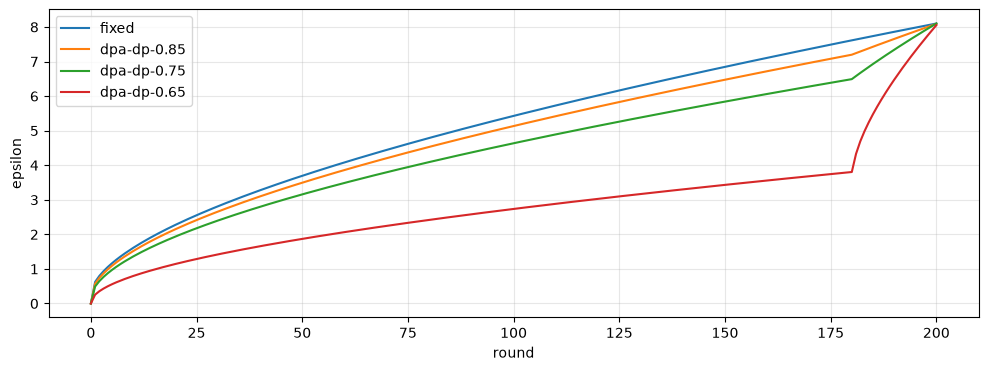

In [10]:
rounds=200
noise_multiplier_switch = 180
n_samples = 4000
batch_size = 32

epsilon_data = {}
epsilon_data["fixed"] = epsilon_curve(1.00, 1.00, opacus.accountants.PRVAccountant())
epsilon_data["dpa-dp-0.85"] = epsilon_curve(1.03, 0.85, opacus.accountants.PRVAccountant())
epsilon_data["dpa-dp-0.75"] = epsilon_curve(1.09, 0.75, opacus.accountants.PRVAccountant())
epsilon_data["dpa-dp-0.65"] = epsilon_curve(1.53, 0.65, opacus.accountants.PRVAccountant())
print({k: a[-1] for k, a in epsilon_data.items()})
plot_epsilon(epsilon_data)

##### page break

### Accuracy between epsilon consumption strategies
tune_layers: 1, learning_rate: 0.01, batch_size: 32, max_grad_norm: 2

As expected, during normal rounds all DPA-DP strategies show slightly worse but comparable accuracy to the fixed baseline. After simulated disaster onset at round 180, the low and medium strategies finish with better accuracy than the fixed baseline. The high-profile strategy 0.65 is notably performing worse in both phases.

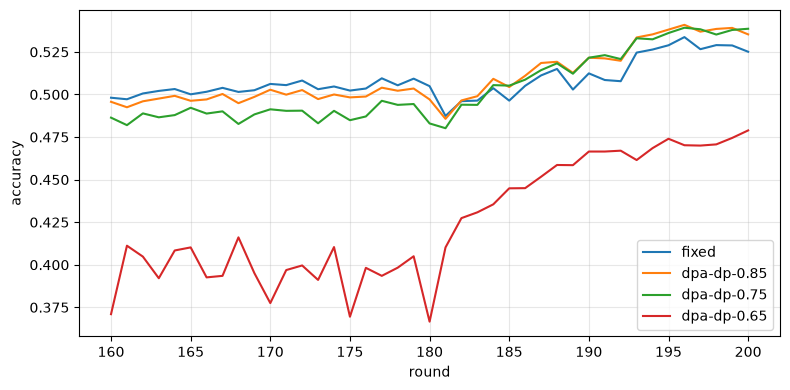

In [5]:
flwr_accuracy("budget3", 160)

##### page break

### Simulated disaster accuracy between strategies
Accuracy computed separately for the labels "bird" and "deer", since they represent disaster images and matter most requiring separate attention. Accuracy is zero for all strategies up to round 180, as the model hasn't yet seen these images. After round 180, all profiles show distinguishably better accuracy than the baseline.


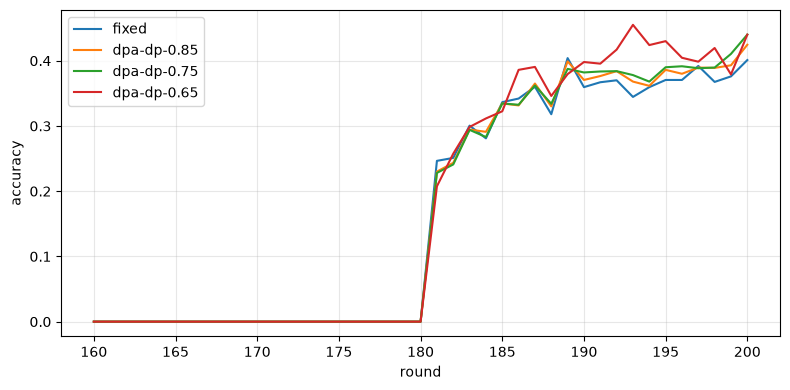

In [12]:
flwr_accuracy("budget3_sub", 160)

##### page break

### Loss between strategies
Loss is comparable (roughly 4-5) across all strategies except high 0.65, which is around 6. Together with the accuracy drop, this indicates the 1.53 noise multiplier was high enough to prevent the model from learning normal images.

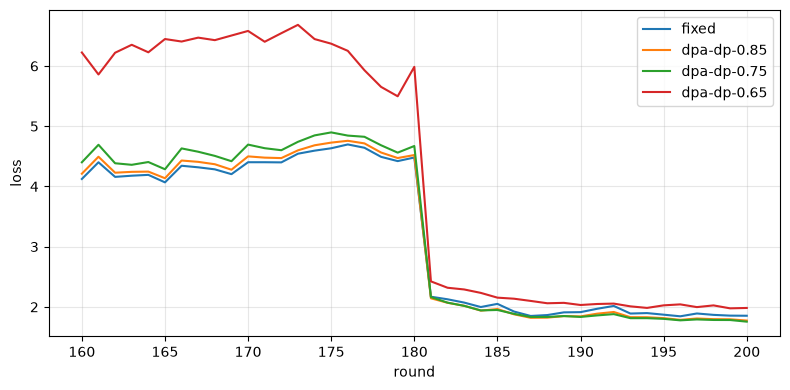

In [9]:
flwr_accuracy("budget3", 160, "loss")